# Predictive Model — Repurchase Probability

## Objetivo

Construir un modelo de clasificación binaria que prediga si un usuario 
tiene un comportamiento de recompra consolidado, definido como una tasa 
de reorden >= 0.5 en su próximo pedido.

## Estructura

1. Baseline: Logistic Regression
2. Modelo principal: XGBoost
3. Comparación de métricas
4. Interpretabilidad con SHAP
5. Decisión de umbral como criterio de negocio

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import shap

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

OUTPUTS_DIR = os.path.join('..', 'outputs')

df_model = pd.read_csv(os.path.join(OUTPUTS_DIR, 'instacart_features.csv'))

FEATURES = ['total_orders', 'total_items', 'distinct_products', 'reorder_rate',
            'avg_days_between', 'std_days_between', 'most_frequent_dow',
            'most_frequent_hour', 'avg_cart_size', 'days_since_last_order']

X = df_model[FEATURES]
y = df_model['target']

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"\nBalance de clases:")
print(y.value_counts(normalize=True).round(3))

Shape X: (131209, 10)
Shape y: (131209,)

Balance de clases:
target
1    0.666
0    0.334
Name: proportion, dtype: float64


---
## 1. Split de datos

Se usa un 80/20 con `stratify=y` para garantizar que la proporción 
de clases se preserve en train y test. La semilla fija reproducibilidad.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"\nBalance en train: {y_train.mean():.3f} positivos")
print(f"Balance en test:  {y_test.mean():.3f} positivos")

X_train: (104967, 10)  |  X_test: (26242, 10)

Balance en train: 0.666 positivos
Balance en test:  0.666 positivos


---
## 2. Baseline: Logistic Regression

La regresión logística actúa como benchmark interpretable. 
Requiere escalado de features porque es sensible a la magnitud 
de las variables.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr  = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression")
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")
print(f"\n{classification_report(y_test, y_pred_lr)}")

Logistic Regression

ROC-AUC: 0.7859

              precision    recall  f1-score   support

           0       0.64      0.50      0.56      8753
           1       0.77      0.86      0.81     17489

    accuracy                           0.74     26242
   macro avg       0.71      0.68      0.69     26242
weighted avg       0.73      0.74      0.73     26242



---
## 3. Modelo principal: XGBoost

XGBoost no requiere escalado de features. Se usan hiperparámetros 
conservadores para evitar overfitting dado el tamaño del dataset.

In [6]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

y_pred_xgb  = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost")
print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"\n{classification_report(y_test, y_pred_xgb)}")

XGBoost

ROC-AUC: 0.7900

              precision    recall  f1-score   support

           0       0.64      0.50      0.57      8753
           1       0.78      0.86      0.82     17489

    accuracy                           0.74     26242
   macro avg       0.71      0.68      0.69     26242
weighted avg       0.73      0.74      0.73     26242



### Comparación de modelos y curvas ROC

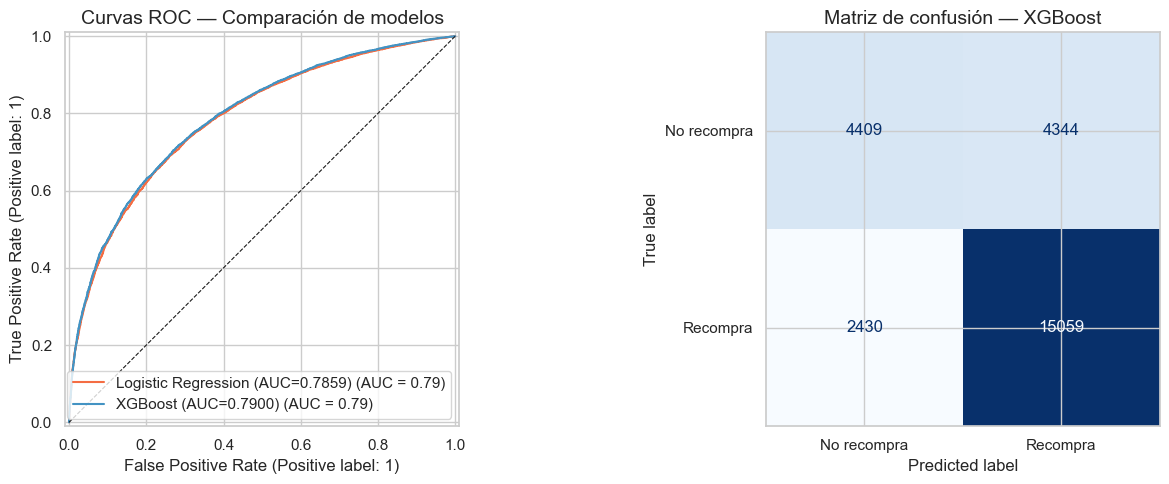

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(
    y_test, y_proba_lr, name=f'Logistic Regression (AUC={roc_auc_score(y_test, y_proba_lr):.4f})',
    ax=axes[0], color='#f46d43'
)
RocCurveDisplay.from_predictions(
    y_test, y_proba_xgb, name=f'XGBoost (AUC={roc_auc_score(y_test, y_proba_xgb):.4f})',
    ax=axes[0], color='#4393c3'
)
axes[0].plot([0,1], [0,1], 'k--', linewidth=0.8)
axes[0].set_title('Curvas ROC — Comparación de modelos')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb, ax=axes[1],
    colorbar=False, cmap='Blues',
    display_labels=['No recompra', 'Recompra']
)
axes[1].set_title('Matriz de confusión — XGBoost')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Interpretabilidad con SHAP

SHAP (SHapley Additive exPlanations) cuantifica la contribución 
de cada feature a la predicción de cada usuario. Se usa una muestra 
de 2.000 usuarios del test set para mantener tiempos de cómputo 
razonables sin perder representatividad.

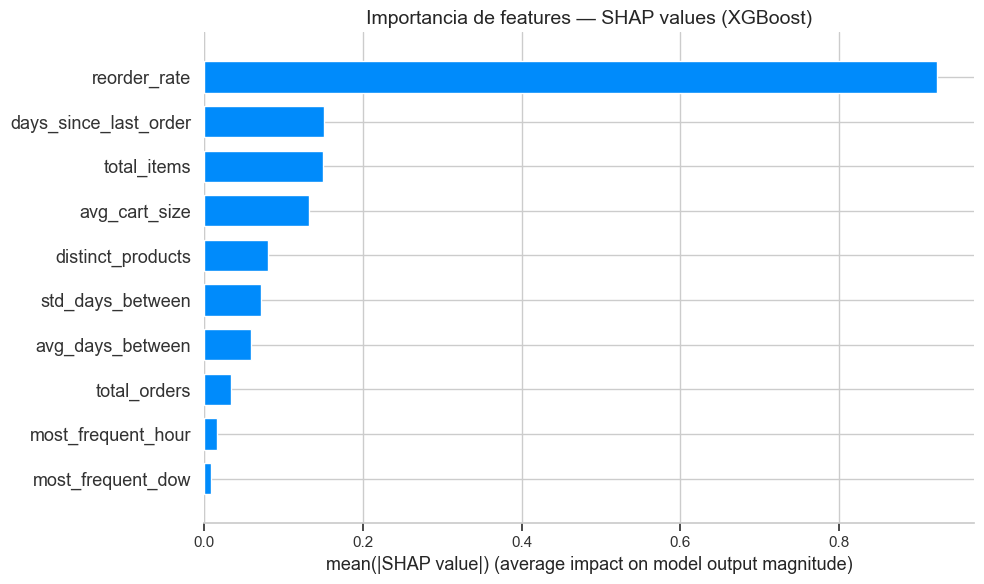

In [8]:
sample_idx = X_test.sample(2000, random_state=42).index
X_sample   = X_test.loc[sample_idx]

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, plot_type='bar',
                  show=False, plot_size=None)
ax = plt.gca()
ax.set_title('Importancia de features — SHAP values (XGBoost)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'shap_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

### Dirección del efecto por feature (SHAP beeswarm)

El beeswarm muestra para cada observación si el valor de la feature 
empuja la predicción hacia recompra (derecha) o no recompra (izquierda), 
y con qué magnitud.

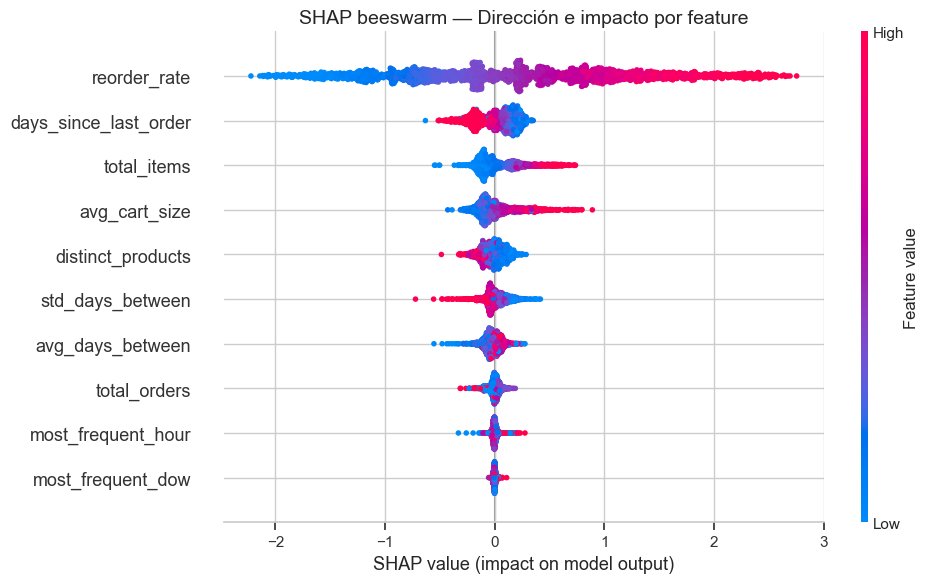

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False, plot_size=None)
ax = plt.gca()
ax.set_title('SHAP beeswarm — Dirección e impacto por feature')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'shap_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Umbral de decisión

El umbral por defecto de 0.5 no es necesariamente el óptimo para 
el negocio. La elección depende del costo relativo entre dos tipos 
de error:

- **Falso positivo**: predecir recompra cuando no ocurre. 
  Costo: campaña de retención enviada a un usuario que ya iba a comprar 
  (desperdicio de presupuesto de marketing).
- **Falso negativo**: predecir no recompra cuando sí ocurre. 
  Costo: no intervenir sobre un usuario que estaba en riesgo de no volver.

Si el costo de perder un cliente supera el costo de una campaña 
innecesaria, el umbral debe bajarse para priorizar recall sobre 
precision. Esta es una dec

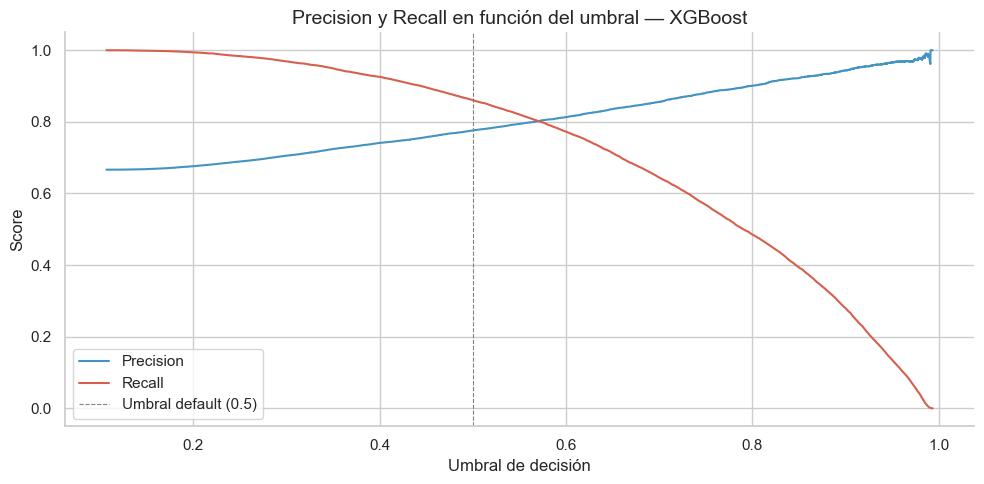

In [10]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_xgb)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precision[:-1], color='#4393c3', label='Precision')
ax.plot(thresholds, recall[:-1], color='#d6604d', label='Recall')
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8, label='Umbral default (0.5)')
ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('Score')
ax.set_title('Precision y Recall en función del umbral — XGBoost')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_DIR, 'threshold_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## Conclusiones

| Modelo | ROC-AUC | Accuracy | F1 (clase 1) |
|---|---|---|---|
| Logistic Regression | 0.7859 | 0.74 | 0.81 |
| XGBoost | 0.7900 | 0.74 | 0.82 |

La mejora de XGBoost sobre el baseline es marginal (0.004 AUC), 
lo que indica que las features construidas tienen principalmente 
relaciones lineales con el target. Ambos modelos son útiles y 
defendibles según el contexto de uso.

**Features más importantes (SHAP):**
1. `reorder_rate`: el predictor dominante por amplio margen.
2. `days_since_last_order`: usuarios con más días de inactividad 
   tienen menor probabilidad de recompra.
3. `total_items` y `avg_cart_size`: usuarios con historial de 
   compra voluminoso reordenan más.
4. `most_frequent_hour` y `most_frequent_dow`: sin poder predictivo 
   relevante.

**Umbral de decisión:** se recomienda evaluar umbrales entre 0.3 y 0.4 
si el negocio prioriza no perder clientes sobre el costo de campañas 
innecesarias.